<div style="max-width:300px; float: left; margin-right: 1em">

![](Figures/fcfm_das.svg)

</div>
<span style="color: red;">Departamento de Astronomía, Universidad de Chile</span> <br>
Facultad de Ciencias Físicas y Matemáticas <br>
Universidad de Chile <br>
AS4501 - Astroinformatica <br>
Otoño 2026 <br>
Profesor: Francisco Förster Burón <br>
<strong>Profesores Auxilares y Autores: Benjamin Carrera y Steve Jurado</strong> <br>

> This notebook is created based on the notes from 
> - ([@fforster](https://github.com/fforster)) Francisco Förster: - **Main Notes 2026/01**   
>   - https://github.com/fforster/AS4501/tree/main
> - ([@thevalentino](https://github.com/thevalentino)) Valentino Gonzales:
>   - https://github.com/thevalentino/AS450-astroinformatica
> - ([@cefuente](https://github.com/cefuente)) Cesar Fuentes
>   - https://github.com/cefuente/astroinformatica
> and previour teachers assistants
> - ([@m-fuentealba](https://github.com/m-fuentealba)) Melissa Fuentealba 
> - ([@jvines](https://github.com/jvines)) José Vines
> - ([@PauCaBu](https://github.com/PauCaBu)) Paula Cáceres Burgos
> - ([@JavieraTGrey](https://github.com/JavieraTGrey)) Javiera Toro Grey

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from astropy.table import vstack

rc_params = {
   'mathtext.fontset': 'cm',     # Set default mathtext font
   'font.family': 'STIXGeneral', # Set default font family
   'xtick.direction': 'in',      # Set default xtickdirecion
   'xtick.minor.visible': True,  # visibility of minor ticks on x-axis
   'ytick.direction': 'in',      # Set default ytickdirecion
   'ytick.minor.visible': True,  # visibility of minor ticks on y-axis
   'grid.linestyle': ':',        # Set grid linestyle
   'grid.alpha': 0.6,            # Set grid transparency
   
}

In [3]:
from astroquery.gaia import Gaia


The archive is unstable and may perform below expectations. If launching multiple, consecutive, heavy queries through Python, please space them out (e.g., using sleep(1)) to avoid overloading the system. Please contact the Gaia helpdesk in case of questions (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk). Workaround solutions for the issues following the December 2025 infrastructure upgrade: https://www.cosmos.esa.int/web/gaia/news#WorkaroundArchive


In [17]:
n_samples = 500 
tables = []
classes = ['RR', 'CEP', 'DSCT/GDOR/SXPHE']

for cls in classes:
    print(f"\n[1] Iniciando consulta para: {cls}...")
    
    q = f"""
    SELECT TOP {n_samples}
        g.source_id, g.ra, g.dec, g.parallax, g.pmra, g.pmdec,
        g.phot_g_mean_mag, g.bp_rp,
        v.best_class_name AS target_class
    FROM gaiadr3.gaia_source AS g
    JOIN gaiadr3.vari_classifier_result AS v
        ON g.source_id = v.source_id
    WHERE g.parallax_over_error > 5
        AND g.bp_rp IS NOT NULL
        AND v.best_class_name = '{cls}'
    ORDER BY g.random_index
    """
    
    # Forzamos una limpieza de caché en caso de que astroquery haya guardado un error previo
    job = Gaia.launch_job_async(q)
    t = job.get_results()
    
    # AUDITORÍA DE DESCARGA
    print(f" -> Filas descargadas desde Gaia: {len(t)}")
    
    if len(t) > 0:
        tables.append(t)

print("\n[2] Apilando tablas (vstack)...")
results = vstack(tables)

# Convertimos a Pandas
df = results.to_pandas()

# Forzamos la columna target_class a string estándar (a veces Astropy la deja como bytes tipo b'CEP')
df['target_class'] = df['target_class'].apply(lambda x: x.decode('utf-8') if isinstance(x, bytes) else str(x))

print(f" -> Tamaño del DataFrame crudo: {df.shape[0]} filas.")
print(df['target_class'].value_counts())

print("\n[3] Aplicando limpieza (dropna)...")
df_clean = df.dropna()
print(f" -> Tamaño del DataFrame tras dropna(): {df_clean.shape[0]} filas.")

# Si dropna() borró demasiado, mostramos qué columnas tenían NaNs en los datos originales
if df_clean.shape[0] < df.shape[0]:
    print(" -> ¡Atención! Se perdieron filas. NaNs por columna en los datos originales:")
    print(df.isna().sum())

print("\n[4] Mezclando datos (shuffle)...")
df_final = df_clean.sample(frac=1, random_state=42).reset_index(drop=True)

print("\nDistribución final de clases lista para Machine Learning:")
print(df_final['target_class'].value_counts())


[1] Iniciando consulta para: RR...


INFO: Query finished. [astroquery.utils.tap.core]
 -> Filas descargadas desde Gaia: 500

[1] Iniciando consulta para: CEP...
INFO: Query finished. [astroquery.utils.tap.core]
 -> Filas descargadas desde Gaia: 500

[1] Iniciando consulta para: DSCT/GDOR/SXPHE...
INFO: Query finished. [astroquery.utils.tap.core]
 -> Filas descargadas desde Gaia: 0

[2] Apilando tablas (vstack)...
 -> Tamaño del DataFrame crudo: 1000 filas.
target_class
RR     500
CEP    500
Name: count, dtype: int64

[3] Aplicando limpieza (dropna)...
 -> Tamaño del DataFrame tras dropna(): 1000 filas.

[4] Mezclando datos (shuffle)...

Distribución final de clases lista para Machine Learning:
target_class
CEP    500
RR     500
Name: count, dtype: int64


In [19]:
df_final.columns

Index(['source_id', 'ra', 'dec', 'parallax', 'pmra', 'pmdec',
       'phot_g_mean_mag', 'bp_rp', 'target_class'],
      dtype='str')

In [21]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# --- 1. FEATURE ENGINEERING ---
# Calculamos la distancia en parsecs (Gaia entrega el paralaje en mas)
distancia_pc = 1000 / df_final['parallax']

# Calculamos la Magnitud Absoluta en la banda G
df_final['abs_mag_g'] = df_final['phot_g_mean_mag'] - 5 * np.log10(distancia_pc) + 5

# --- 2. DEFINIR VARIABLES (X) Y ETIQUETAS (y) ---
# Seleccionamos las características físicas que usará el modelo
# 'bp_rp' nos da el color (temperatura), 'abs_mag_g' la luminosidad intrínseca,
# y añadimos los movimientos propios para ver si la cinemática ayuda.
caracteristicas = ['abs_mag_g', 'bp_rp', 'pmra', 'pmdec']

X = df_final[caracteristicas]
y = df_final['target_class']

# --- 3. TRAIN / TEST SPLIT ---
# stratify=y asegura que la proporción de clases se mantenga igual en ambos conjuntos
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Datos para entrenar: {X_train.shape[0]} estrellas")
print(f"Datos para evaluar: {X_test.shape[0]} estrellas\n")

# --- 4. ENTRENAR EL MODELO ---
# Instanciamos un Bosque Aleatorio con 100 árboles de decisión
clf = RandomForestClassifier(n_estimators=100, random_state=42)

# ¡Aquí ocurre la magia del aprendizaje!
print("Entrenando el modelo...")
clf.fit(X_train, y_train)

# --- 5. PREDICCIONES Y EVALUACIÓN ---
print("Realizando predicciones sobre el conjunto de prueba...")
y_pred = clf.predict(X_test)

# Mostramos el reporte de métricas
print("\n--- Reporte de Clasificación ---")
print(classification_report(y_test, y_pred))

Datos para entrenar: 700 estrellas
Datos para evaluar: 300 estrellas

Entrenando el modelo...
Realizando predicciones sobre el conjunto de prueba...

--- Reporte de Clasificación ---
              precision    recall  f1-score   support

         CEP       0.98      0.93      0.96       150
          RR       0.94      0.98      0.96       150

    accuracy                           0.96       300
   macro avg       0.96      0.96      0.96       300
weighted avg       0.96      0.96      0.96       300



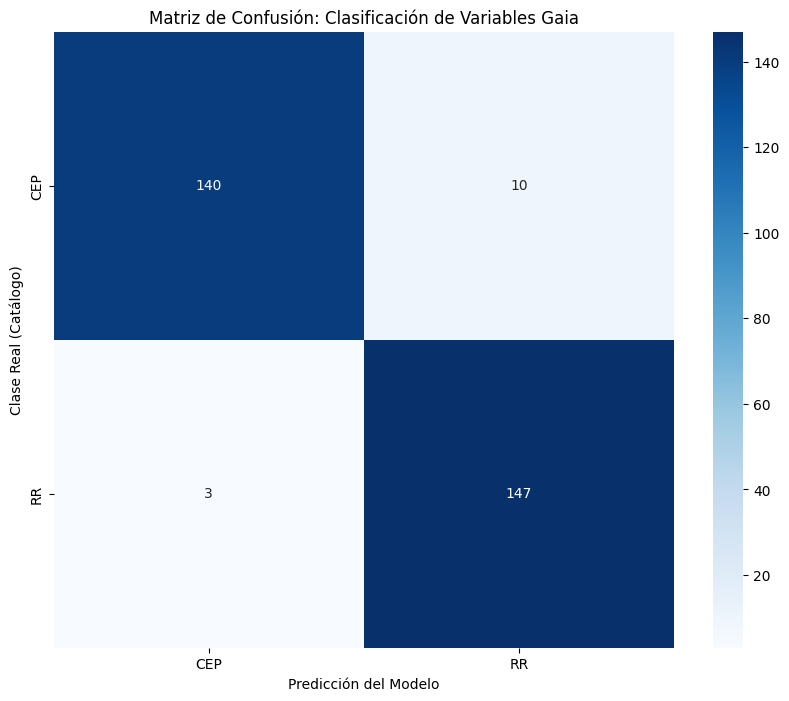

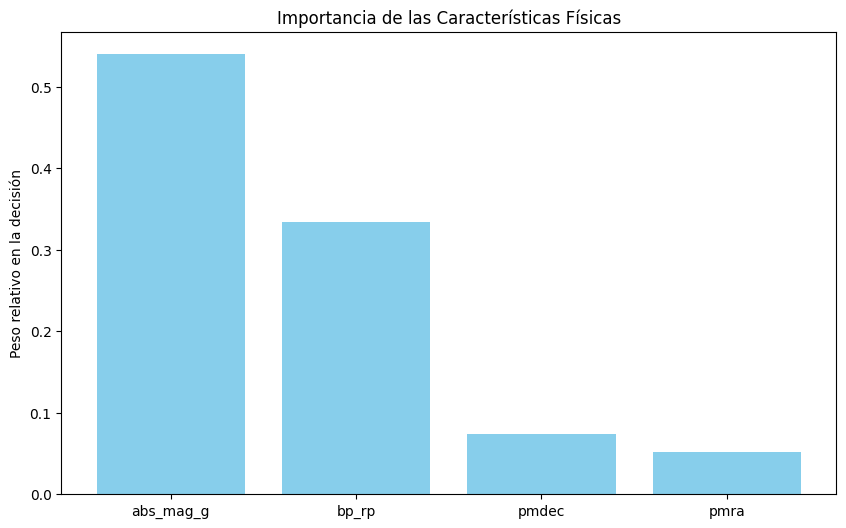

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. MATRIZ DE CONFUSIÓN
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=clf.classes_, yticklabels=clf.classes_)
plt.title('Matriz de Confusión: Clasificación de Variables Gaia')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Clase Real (Catálogo)')
plt.show()

# 2. IMPORTANCIA DE CARACTERÍSTICAS
importancias = clf.feature_importances_
indices = np.argsort(importancias)[::-1]
nombres_features = [caracteristicas[i] for i in indices]

plt.figure(figsize=(10, 6))
plt.title("Importancia de las Características Físicas")
plt.bar(range(X.shape[1]), importancias[indices], align="center", color='skyblue')
plt.xticks(range(X.shape[1]), nombres_features)
plt.ylabel("Peso relativo en la decisión")
plt.show()

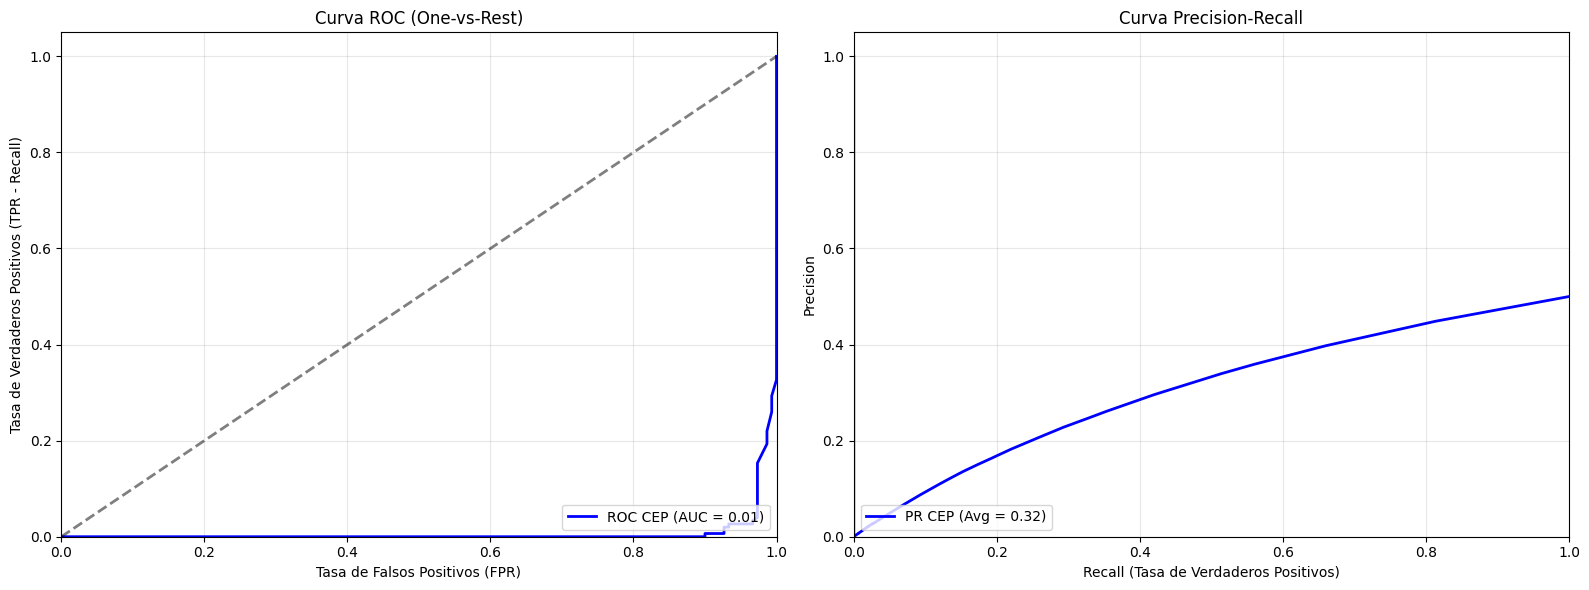

In [24]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize

# 1. Binarizar las etiquetas para el enfoque One-vs-Rest
# Convierte ['RR', 'CEP', 'DSCT'] a columnas de 0s y 1s
y_test_bin = label_binarize(y_test, classes=clf.classes_)
n_classes = y_test_bin.shape[1]

# 2. Obtener las probabilidades de predicción del modelo
# En lugar de clf.predict(), usamos predict_proba()
y_score = clf.predict_proba(X_test)

# Configurar los gráficos (1 fila, 2 columnas)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Colores para cada clase
colors = ['blue', 'green', 'darkorange']

for i, color in zip(range(n_classes), colors):
    clase_actual = clf.classes_[i]
    
    # --- GRÁFICO 1: Curva ROC ---
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    ax1.plot(fpr, tpr, color=color, lw=2, 
             label=f'ROC {clase_actual} (AUC = {roc_auc:.2f})')
    
    # --- GRÁFICO 2: Curva Precision-Recall ---
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_score[:, i])
    avg_pr = average_precision_score(y_test_bin[:, i], y_score[:, i])
    ax2.plot(recall, precision, color=color, lw=2, 
             label=f'PR {clase_actual} (Avg = {avg_pr:.2f})')

# Formato del Gráfico ROC
ax1.plot([0, 1], [0, 1], 'k--', lw=2, alpha=0.5) # Línea de clasificador aleatorio
ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.set_xlabel('Tasa de Falsos Positivos (FPR)')
ax1.set_ylabel('Tasa de Verdaderos Positivos (TPR - Recall)')
ax1.set_title('Curva ROC (One-vs-Rest)')
ax1.legend(loc="lower right")
ax1.grid(alpha=0.3)

# Formato del Gráfico Precision-Recall
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('Recall (Tasa de Verdaderos Positivos)')
ax2.set_ylabel('Precision')
ax2.set_title('Curva Precision-Recall')
ax2.legend(loc="lower left")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

/home/jurados/AS4501_Astroinformatic/Astroinformatic/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


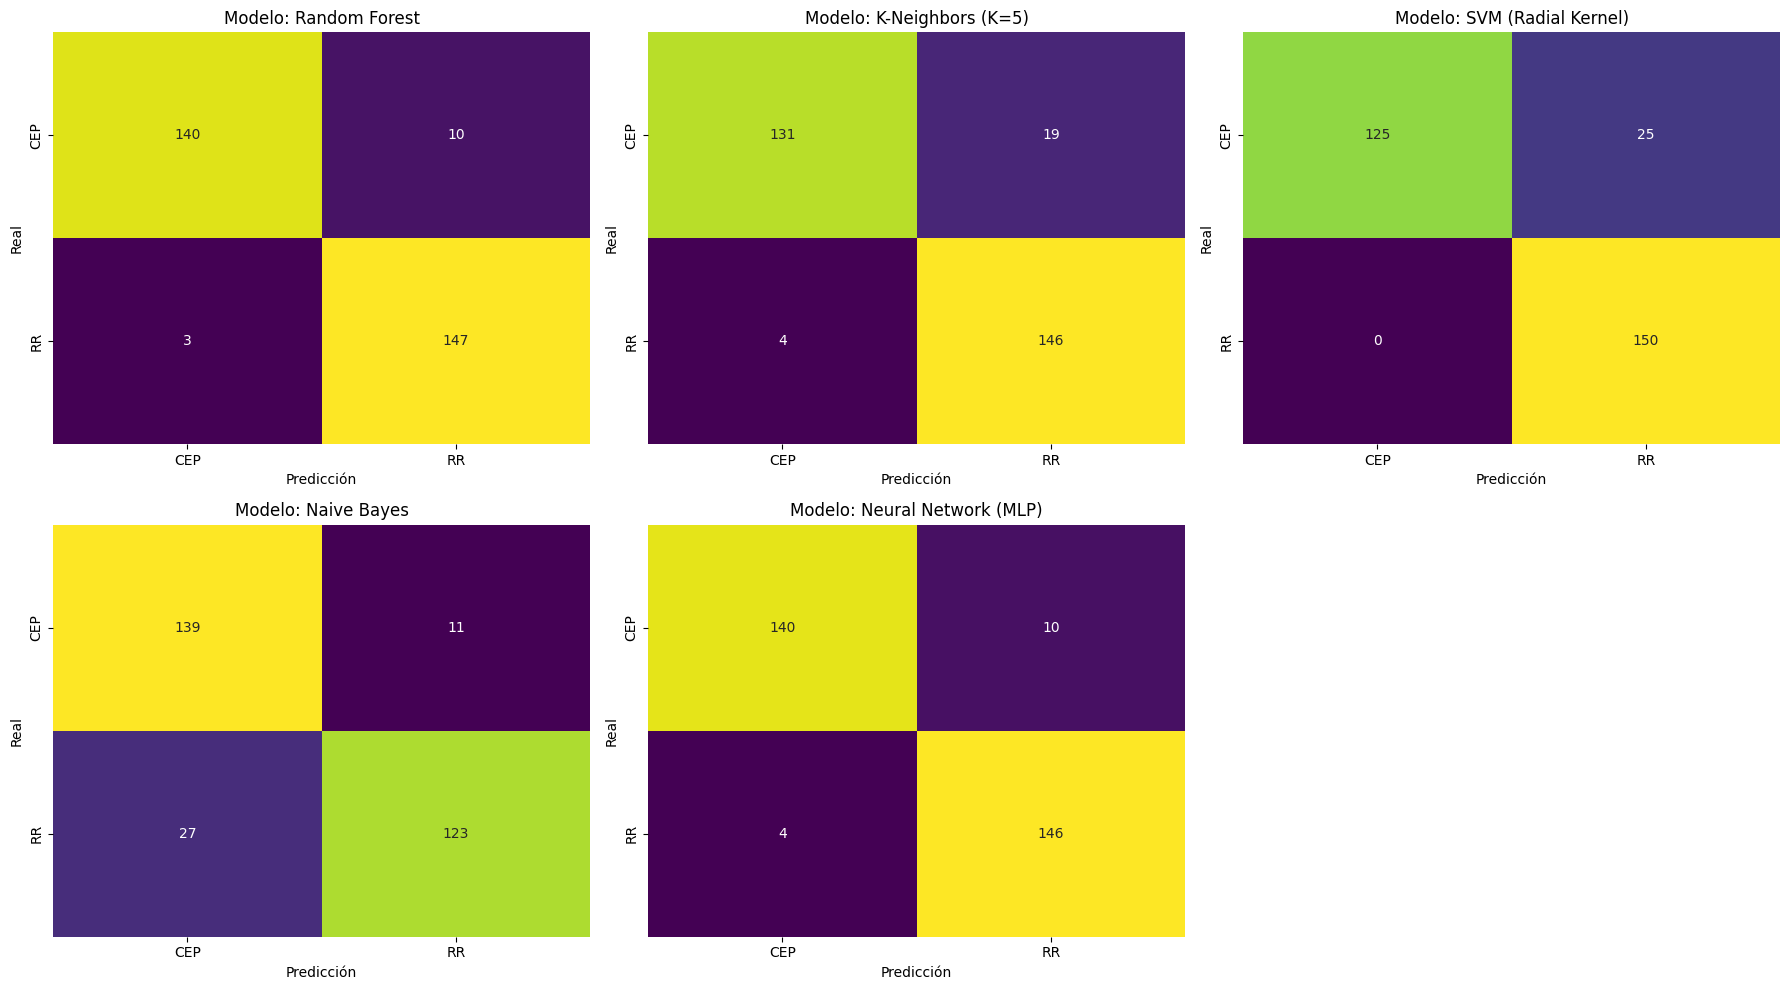

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix

# 1. Definimos el diccionario de modelos
modelos = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "K-Neighbors (K=5)": KNeighborsClassifier(n_neighbors=5),
    "SVM (Radial Kernel)": SVC(probability=True, random_state=42),
    "Naive Bayes": GaussianNB(),
    "Neural Network (MLP)": MLPClassifier(max_iter=500, random_state=42)
}

# 2. Configuramos la grilla de gráficos (2 filas, 3 columnas)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# 3. Entrenamos y graficamos cada uno
for i, (nombre, clf) in enumerate(modelos.items()):
    ax = axes[i]
    
    # Entrenamiento
    clf.fit(X_train, y_train)
    
    # Predicción
    y_pred_m = clf.predict(X_test)
    
    # Matriz de confusión
    cm = confusion_matrix(y_test, y_pred_m, labels=clf.classes_)
    
    # Visualización
    sns.heatmap(cm, annot=True, fmt='d', cmap='viridis', 
                xticklabels=clf.classes_, yticklabels=clf.classes_, ax=ax, cbar=False)
    
    ax.set_title(f'Modelo: {nombre}')
    ax.set_xlabel('Predicción')
    ax.set_ylabel('Real')

# Eliminamos el último eje vacío (el sexto)
fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

In [26]:
# --- CREACIÓN DEL ESCENARIO DESBALANCEADO ---
# Supongamos que tenemos 2000 RR Lyrae pero solo 50 Cefeidas y 50 Delta Scuti
df_rr = df_final[df_final['target_class'] == 'RR'].sample(2000, replace=True)
df_cep = df_final[df_final['target_class'] == 'CEP'].sample(50)
df_dsct = df_final[df_final['target_class'] == 'DSCT/GDOR/SXPHE'].sample(50)

df_imbalanced = pd.concat([df_rr, df_cep, df_dsct]).sample(frac=1)

# Preparar datos
X_imb = df_imbalanced[['abs_mag_g', 'bp_rp', 'pmra', 'pmdec']]
y_imb = df_imbalanced['target_class']
X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(X_imb, y_imb, test_size=0.3, stratify=y_imb)

# --- ENTRENAMIENTO ---
clf_imb = RandomForestClassifier(random_state=42)
clf_imb.fit(X_train_i, y_train_i)
y_pred_i = clf_imb.predict(X_test_i)

# --- EVALUACIÓN CRÍTICA ---
print("--- RESULTADOS CON DATOS DESBALANCEADOS ---")
print(f"Exactitud Balanceada: {balanced_accuracy_score(y_test_i, y_pred_i):.2f}")
print(classification_report(y_test_i, y_pred_i))

ValueError: a must be greater than 0 unless no samples are taken

In [27]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Definimos el esquema de validación: 5 divisiones (Folds)
# Shuffle=True es vital para asegurar que los datos no estén ordenados
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Usamos el dataset original balanceado (X, y definido anteriormente)
clf_cv = RandomForestClassifier(n_estimators=100, random_state=42)

# Calculamos la exactitud para cada uno de los 5 experimentos
scores = cross_val_score(clf_cv, X, y, cv=skf, scoring='accuracy')

print("--- RESULTADOS DE VALIDACIÓN CRUZADA (5-FOLD) ---")
print(f"Exactitudes por Fold: {scores}")
print(f"Exactitud Promedio: {scores.mean():.4f} +/- {scores.std():.4f}")

# Esto demuestra la estabilidad del modelo ante diferentes subconjunt

--- RESULTADOS DE VALIDACIÓN CRUZADA (5-FOLD) ---
Exactitudes por Fold: [0.95  0.96  0.985 0.97  0.945]
Exactitud Promedio: 0.9620 +/- 0.0144
